# 6 — Dtypes, density and corrections

**Theme:** changing what the numbers *mean* before analysing them.

A size distribution can be expressed as number, surface, volume or mass; mass
depends on an assumed particle density; and a sampling line removes some of the
smallest particles before they are ever counted. This notebook covers those
conversions and corrections, plus the derived PM fractions built on top of
them.

In [1]:
import aerosoltools as at

elpi = at.load_elpi_file("../../tests/data/Sample_ELPI.txt")
print("dtype  :", elpi.dtype)
print("unit   :", elpi.unit)
print("density:", elpi.density, "g/cm3")

dtype  : dN
unit   : cm⁻³
density: 0.14 g/cm3


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/runner/work/aerosoltools/aerosoltools/src/aerosoltools/loaders/elpi.py:525: RuntimeWarning: ELPI density is not 1.0 g/cm3; bin edges were estimated from geometric means of CalculatedDi values.
  return load_elpi_file_txt(


The warning on load is the point of this notebook: the file records a particle
density other than 1.0 g/cm³, and every mass-based quantity depends on it.

## Distribution types

`dtype` records what the numbers are. `dtype_converter` converts between them:

| dtype | quantity |
|---|---|
| `dN` | number |
| `dS` | surface area |
| `dV` | volume |
| `dM` | mass |

The conversion is geometric — number to volume uses the bin diameters, volume
to mass multiplies by density — so it only makes sense on size-resolved data.

In [2]:
mass = elpi.copy_self()
mass.dtype_converter("dM")
print("dtype:", mass.dtype)
print("unit :", mass.unit)

dtype: dM
unit : µg/m³


In [3]:
surface = elpi.copy_self()
surface.dtype_converter("dS")
print("dtype:", surface.dtype, "| unit:", surface.unit)

dtype: dS | unit: nm²/cm³


## Density

Mass is number × volume × density, so an assumed density propagates into every
mass result. `set_density` changes it.

In [4]:
denser = elpi.copy_self()
denser.set_density(2.0)
denser.dtype_converter("dM")

print(f"density 1.5 -> mean mass {mass.total_concentration.mean():.1f} {mass.unit}")
print(f"density 2.0 -> mean mass {denser.total_concentration.mean():.1f} {denser.unit}")

density 1.5 -> mean mass 124.6 µg/m³
density 2.0 -> mean mass 148.2 µg/m³


Density is an *assumption* unless you have measured it. Reporting the value you
used matters as much as the result.

For the ELPI specifically, density also affects the size axis itself: the
aerodynamic diameters the instrument reports are recomputed when you call
`set_density`, because a denser particle of the same aerodynamic size is
physically smaller.

## Per-column dtypes and units

Multi-channel instruments carry a dtype and unit per column. `dtype_of` and
`unit_of` answer for one column.

In [5]:
dust = at.load_dusttrak_file("../../tests/data/Sample_DustTrak.csv")

print("PM1  ->", dust.dtype_of("PM1"), dust.unit_of("PM1"))
print("PM10 ->", dust.dtype_of("PM10"), dust.unit_of("PM10"))
print()
print("all columns:", dust.column_units)

PM1  -> dM µg/m³
PM10 -> dM µg/m³

all columns: {}


## dlogDp normalisation

Instruments use different bin widths, so raw per-bin concentrations are not
comparable between them. Dividing by the width of each bin in log space gives
`dN/dlogDp`, which is.

In [6]:
norm = elpi.copy_self()
norm.normalize_logdp()
print("normalised   :", norm.dtype)

norm.unnormalize_logdp()
print("back to base :", norm.dtype)

normalised   : dN/dlogDp
back to base : dN


Most plotting and fitting works on the normalised form — `plot_psd` normalises
by default — so you rarely call these directly. They matter when you are
exporting numbers for something else, or comparing against data that has
already been normalised.

## Size bins

The bin structure is available directly.

In [7]:
print("number of bins:", len(elpi.bin_mids))
print("first mids  [nm]:", elpi.bin_mids[:5].round(1))
print("first edges [nm]:", elpi.bin_edges[:6].round(1))

number of bins: 14
first mids  [nm]: [ 22.6  88.8 128.7 190.4 287. ]
first edges [nm]: [ 18.8  44.8 106.9 156.5 233.8 362.7]


`rebin_bin_edges` maps the distribution onto a different set of edges — needed
when two instruments must share a size axis before they can be combined or
compared.

In [8]:
elpi.size_data.iloc[:3, :5]

,22.6,88.8,128.7,190.4,287.0
Datetime,,,,,
2023-09-07 09:06:38,0.000,26.76,21.14,31.25,36.22
2023-09-07 09:06:39,10.790,23.07,21.32,30.06,35.63
2023-09-07 09:06:40,5.988,23.08,19.76,30.23,35.89


## Diffusion losses

Small particles are lost to the walls of a sampling line by diffusion, so what
reaches the instrument understates what was in the air. The correction depends
on the tube geometry and the flow through it.

In [9]:
corrected = elpi.correct_diffusion_losses(
    D_tube=0.004,   # inner diameter [m]
    L=1.5,          # tube length [m]
    Q=1.0,          # flow [L/min]
    T=293,          # temperature [K]
    P=101300,       # pressure [Pa]
    inplace=False,
)

ratio = corrected.total_concentration.mean() / elpi.total_concentration.mean()
print(f"mean concentration increased by a factor {ratio:.3f}")

mean concentration increased by a factor 1.017


The correction only ever increases concentrations, and most strongly at the
small end where diffusion is fastest. Compare the two distributions to see
where it acts:

Text(0.5, 1.0, 'Diffusion losses affect the smallest particles most')

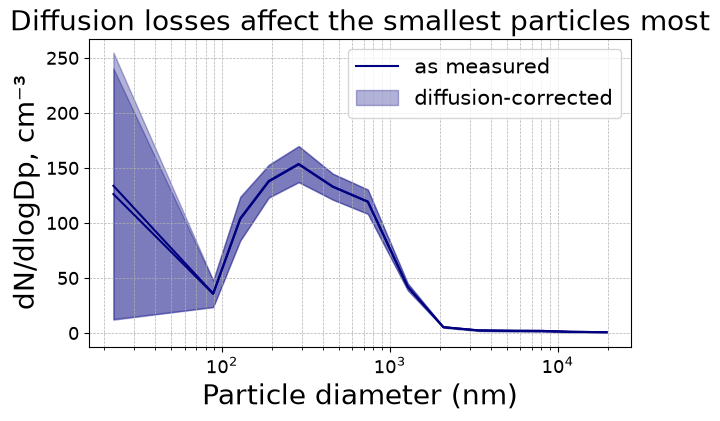

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
elpi.plot_psd(ax=ax, activities=["All data"])
corrected.plot_psd(ax=ax, activities=["All data"])
ax.legend(["as measured", "diffusion-corrected"])
ax.set_title("Diffusion losses affect the smallest particles most")

## PM fractions

`pm_calc` integrates the distribution below a cut diameter. Results are cached
in `.extra_data`, so asking twice costs nothing.

In [11]:
elpi.pm_calc(dtype="dM", PM=2.5)
elpi.pm_calc(dtype="dM", PM=4.2)
elpi.pm_calc(dtype="dM", PM=10)

[c for c in elpi.extra_data.columns if c.startswith("PM")]

['PM10', 'PM2.5', 'PM1', 'PM4.2']

`lower_lim` gives a band instead of a cumulative fraction — the mass between
two diameters rather than everything below one.

In [12]:
elpi.pm_calc(dtype="dM", PM=4.0, lower_lim=1.0)

[c for c in elpi.extra_data.columns if c.startswith("PM")]

['PM10', 'PM2.5', 'PM1', 'PM4.2', 'PM1-4']

The same integration is available for number, surface and volume by changing
`dtype` — `dN` gives `PN`, `dS` gives `PS`, `dV` gives `PV`. These are the
metric names accepted by `summarize_exposure`, see
[4 — Statistics and exposure](04-statistics-and-exposure.ipynb).

---

**Next:** [7 — Combining datasets](07-combining-datasets.ipynb).